In [11]:
#!pip install xgboost lightgbm catboost

In [12]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import OrdinalEncoder


import xgboost as xgb
import lightgbm as lgb
import catboost as cb

sns.set_theme(style="whitegrid")

In [13]:
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print(X.head())
print()

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape[0]}")
print(f"Размер валидационной выборки: {X_val.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

Размер обучающей выборки: 12384
Размер валидационной выборки: 4128
Размер тестовой выборки: 4128


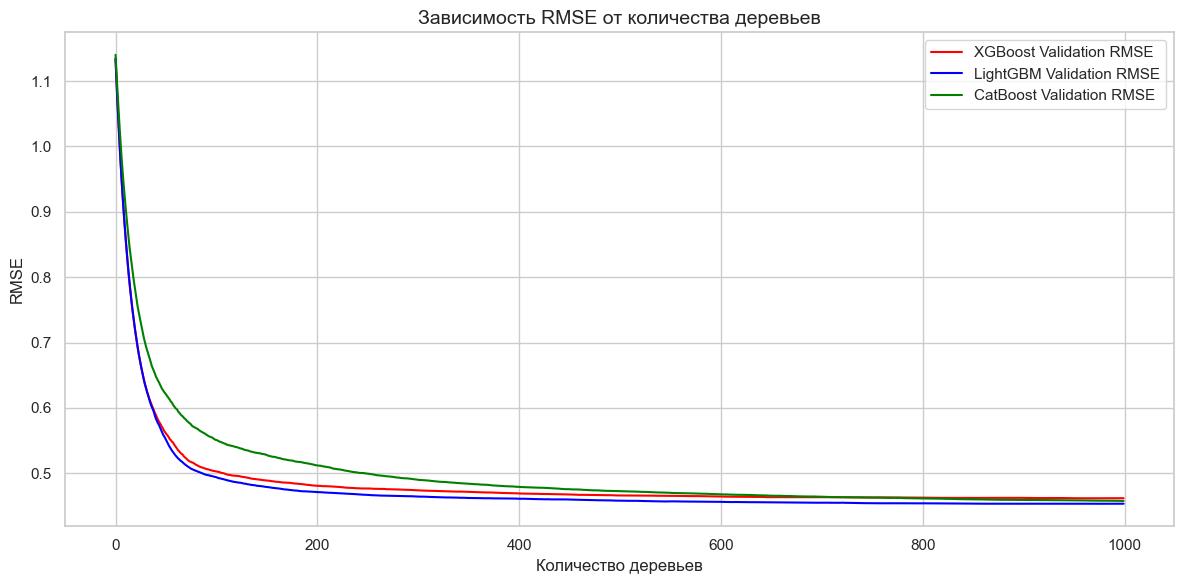

In [14]:
MAX_TREES = 1000
LEARNING_RATE = 0.05

xgb_model = xgb.XGBRegressor(n_estimators=MAX_TREES, learning_rate=LEARNING_RATE, random_state=42)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
xgb_rmse = xgb_model.evals_result()['validation_0']['rmse']

lgb_model = lgb.LGBMRegressor(n_estimators=MAX_TREES, learning_rate=LEARNING_RATE, random_state=42, verbose=-1)
lgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='rmse')
lgb_metric_key = list(lgb_model.evals_result_['valid_0'].keys())[0]
lgb_rmse = lgb_model.evals_result_['valid_0'][lgb_metric_key]

cb_model = cb.CatBoostRegressor(iterations=MAX_TREES, learning_rate=LEARNING_RATE, eval_metric='RMSE', random_seed=42)
cb_model.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=False)
cb_rmse = cb_model.evals_result_['learn']['RMSE']
cb_val_rmse = cb_model.evals_result_['validation']['RMSE']

plt.figure(figsize=(12, 6))
plt.plot(xgb_rmse, label='XGBoost Validation RMSE', color='red')
plt.plot(lgb_rmse, label='LightGBM Validation RMSE', color='blue')
plt.plot(cb_val_rmse, label='CatBoost Validation RMSE', color='green')

plt.title('Зависимость RMSE от количества деревьев', fontsize=14)
plt.xlabel('Количество деревьев', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
SELECTED_N_ESTIMATORS = 400

In [16]:
class MyBoost:
    def __init__(self, n=400, lr=0.05, depth=7, subsample=1.0, colsample_bytree=1.0, cat_features=None, seed=42):
        self.n = n
        self.lr = lr
        self.depth = depth
        self.subsample = subsample
        self.colsample_bytree = colsample_bytree
        self.cat_features = cat_features
        self.seed = seed
        
        self.trees = []
        self.trees_features = [] 
        self.encoder = None
        self.cat_cols_idx = []

    def fit(self, X, y):
        np.random.seed(self.seed)
        
        # Нативная поддержка категориальных признаков
        if isinstance(X, pd.DataFrame):
            if self.cat_features is None:
                self.cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
            
            self.cat_cols_idx = [X.columns.get_loc(col) for col in self.cat_features]
            X_arr = X.to_numpy()
        else:
            X_arr = np.array(X)
            if self.cat_features is not None:
                self.cat_cols_idx = self.cat_features 

        # Кодируем категориальные признаки
        if len(self.cat_cols_idx) > 0:
            self.encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
            X_arr[:, self.cat_cols_idx] = self.encoder.fit_transform(X_arr[:, self.cat_cols_idx])

        # Проверяем, что все данные числовые после кодирования    
        X_arr = X_arr.astype(float)
        self.n_features_in_ = X_arr.shape[1]
        
        # Инициализация первого предсказания (среднее по таргету)
        self.initial_leaf = y.mean() if isinstance(y, pd.Series) else np.mean(y)
        predictions = np.zeros(len(y)) + self.initial_leaf
        y_arr = y.to_numpy() if isinstance(y, pd.Series) else np.array(y)

        for _ in range(self.n):
            antigrad = y_arr - predictions
            
            # Subsample: Случайная подвыборка объектов (строк)
            n_samples = int(len(X_arr) * self.subsample)
            row_indices = np.random.choice(len(X_arr), size=n_samples, replace=False)
            
            # Colsample_bytree: Случайная подвыборка признаков (колонок)
            n_cols = int(self.n_features_in_ * self.colsample_bytree)
            col_indices = np.random.choice(self.n_features_in_, size=n_cols, replace=False)
            self.trees_features.append(col_indices)
            
            # Формируем обучающую выборку для конкретного дерева
            X_subset = X_arr[row_indices][:, col_indices]
            y_subset = antigrad[row_indices]
            
            tree = DecisionTreeRegressor(max_depth=self.depth, random_state=self.seed, criterion="friedman_mse")
            tree.fit(X_subset, y_subset)
            self.trees.append(tree)
            
            # Обновляем общие предсказания. 
            predictions += self.lr * tree.predict(X_arr[:, col_indices])

    def predict(self, X):
        if isinstance(X, pd.DataFrame):
            X_arr = X.to_numpy()
        else:
            X_arr = np.array(X)
            
        # Применяем сохраненный энкодер к новым данным
        if self.encoder is not None and len(self.cat_cols_idx) > 0:
            X_arr[:, self.cat_cols_idx] = self.encoder.transform(X_arr[:, self.cat_cols_idx])
            
        X_arr = X_arr.astype(float)
        predictions = np.zeros(len(X_arr)) + self.initial_leaf
        
        for i in range(self.n):
            # Каждое дерево делает предсказание только на своих признаках
            predictions += self.lr * self.trees[i].predict(X_arr[:, self.trees_features[i]])
            
        return predictions

    @property
    def feature_importances_(self):
        # Создаем пустой массив размером с изначальное количество признаков
        importances = np.zeros(self.n_features_in_)
        
        for i in range(self.n):
            tree = self.trees[i]
            features_used = self.trees_features[i]
            
            # Добавляем важность каждого признака в правильную позицию
            importances[features_used] += tree.feature_importances_ * self.lr
            
        # Усредняем по количеству деревьев в ансамбле
        importances /= self.n
        return importances

In [17]:
from sklearn.model_selection import ParameterGrid

X_train_full = pd.concat([X_train, X_val])
y_train_full = np.concatenate([y_train, y_val])

grid_xgb = {
    'learning_rate': [0.05, 0.1],
    'max_depth':[5, 7],
    'subsample': [0.8, 1.0]
}

grid_lgb = {
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 127],
    'subsample':[0.8, 1.0]
}

grid_cat = {
    'learning_rate':[0.05, 0.1],
    'depth': [5, 7],
    'subsample':[0.8, 1.0]
}

def simple_grid_search(model_name, param_grid):
    print(f"--- Запуск Grid Search для {model_name} ---")
    best_rmse = float('inf')
    best_params = None

    start_time = time.time()

    for params in ParameterGrid(param_grid):
        if model_name == 'XGBoost':
            model = xgb.XGBRegressor(**params, n_estimators=SELECTED_N_ESTIMATORS, random_state=42, n_jobs=-1)
        elif model_name == 'LightGBM':
            model = lgb.LGBMRegressor(**params, n_estimators=SELECTED_N_ESTIMATORS, random_state=42, n_jobs=-1, verbose=-1)
        else:
            model = cb.CatBoostRegressor(**params, iterations=SELECTED_N_ESTIMATORS, random_seed=42, thread_count=-1, verbose=0)

        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, preds))

        if rmse < best_rmse:
            best_rmse = rmse
            best_params = params

    total_time = time.time() - start_time
    print(f"Лучший Validation RMSE: {best_rmse:.4f}")
    print(f"Лучшие параметры: {best_params}\n")

    return best_params

best_params_dict = {}
best_params_dict['XGBoost'] = simple_grid_search('XGBoost', grid_xgb)
best_params_dict['LightGBM'] = simple_grid_search('LightGBM', grid_lgb)
best_params_dict['CatBoost'] = simple_grid_search('CatBoost', grid_cat)

--- Запуск Grid Search для XGBoost ---
Лучший Validation RMSE: 0.4604
Лучшие параметры: {'learning_rate': 0.05, 'max_depth': 7, 'subsample': 0.8}

--- Запуск Grid Search для LightGBM ---
Лучший Validation RMSE: 0.4557
Лучшие параметры: {'learning_rate': 0.1, 'num_leaves': 31, 'subsample': 0.8}

--- Запуск Grid Search для CatBoost ---
Лучший Validation RMSE: 0.4564
Лучшие параметры: {'depth': 7, 'learning_rate': 0.1, 'subsample': 1.0}



In [18]:
results = []

for name in['XGBoost', 'LightGBM', 'CatBoost', "MyBoost"]:
    params = best_params_dict.get(name)

    if name == 'XGBoost':
        model = xgb.XGBRegressor(n_estimators=SELECTED_N_ESTIMATORS, random_state=42, n_jobs=-1, **params)
    elif name == 'LightGBM':
        model = lgb.LGBMRegressor(n_estimators=SELECTED_N_ESTIMATORS, random_state=42, n_jobs=-1, verbose=-1, **params)
    elif name == 'MyBoost':
        model = MyBoost()
    else:
        model = cb.CatBoostRegressor(iterations=SELECTED_N_ESTIMATORS, random_seed=42, thread_count=-1, verbose=0, **params)

    start_time = time.time()
    model.fit(X_train_full, y_train_full)
    train_time = time.time() - start_time

    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append({
        "Модель": name,
        "Время обучения": round(train_time, 3),
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4),
        "R2 Score": round(r2, 4)
    })

df_results = pd.DataFrame(results)
display(df_results)

,Модель,Время обучения,MAE,RMSE,R2 Score
0,XGBoost,0.398,0.2910,0.4492,0.8460
1,LightGBM,0.300,0.2862,0.4379,0.8537
2,CatBoost,0.985,0.2967,0.4493,0.8460
3,MyBoost,25.056,0.2957,0.4563,0.8411


In [19]:
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score

# Моя модель
my_model = MyBoost(n=100, lr=0.1, subsample=0.8, colsample_bytree=0.8)
my_model.fit(X_train, y_train)
my_preds = my_model.predict(X_test)
my_r2 = r2_score(y_test, my_preds)

# Библиотечная модель
cat_model = CatBoostRegressor(iterations=100, learning_rate=0.1, silent=True)
cat_model.fit(X_train, y_train)
cat_preds = cat_model.predict(X_test)
cat_r2 = r2_score(y_test, cat_preds)

print(f"MyBoost R2: {my_r2:.4f}")
print(f"CatBoost R2: {cat_r2:.4f}")
print(f"Difference: {abs(my_r2 - cat_r2):.4f}")

MyBoost R2: 0.8287
CatBoost R2: 0.7970
Difference: 0.0317


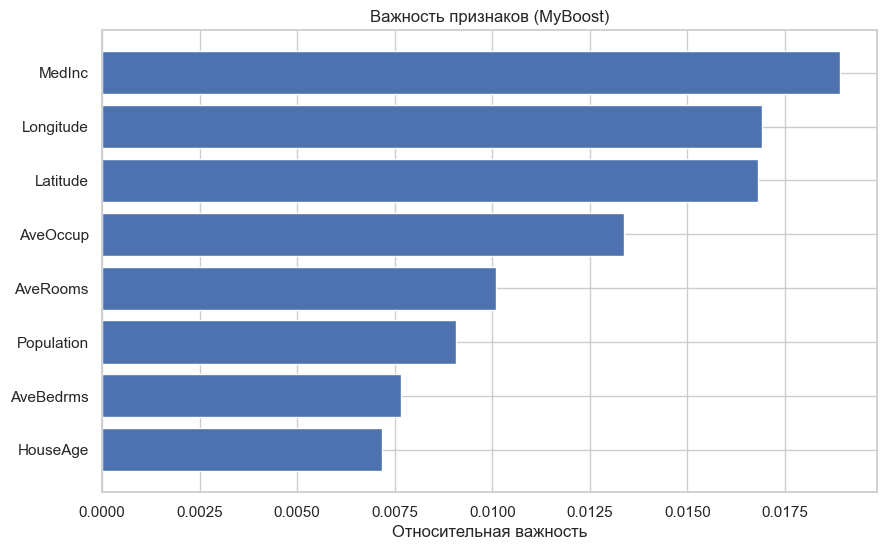

In [20]:
import matplotlib.pyplot as plt

# Получаем важности
importances = my_model.feature_importances_
indices = np.argsort(importances)

# Визуализируем
plt.figure(figsize=(10, 6))
plt.title('Важность признаков (MyBoost)')
plt.barh(range(len(indices)), importances[indices], align='center')
# Если X - это DataFrame, можно добавить названия колонок:
if isinstance(X_train, pd.DataFrame):
    plt.yticks(range(len(indices)), [X_train.columns[i] for i in indices])
plt.xlabel('Относительная важность')
plt.show()